In [4]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import seaborn as sns
import numpy as np

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


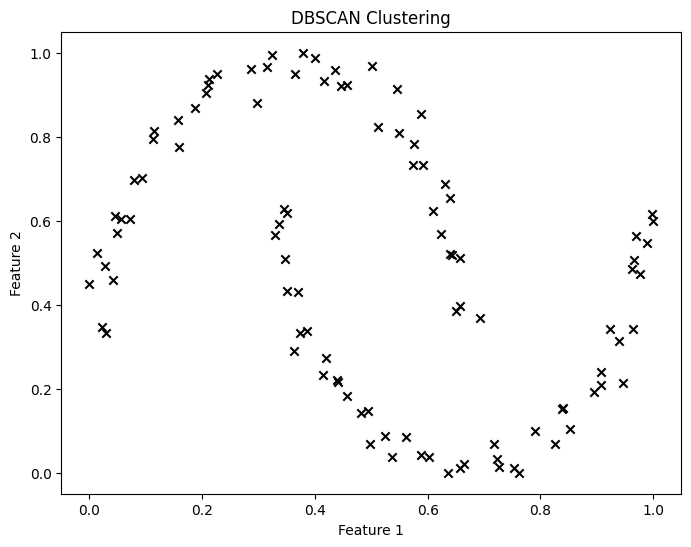

In [5]:
# generate 100 2d points
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.05, random_state=0)
# scale the data to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# fit the model
clusters = [-1] * len(X_scaled)  # Cluster labels for each point

def plot_clusters(X, clusters):
    plt.figure(figsize=(8, 6))
    for i in range(len(clusters)):
        if clusters[i] == -1:
            plt.scatter(X_scaled[i, 0], X_scaled[i, 1], c='k', marker='x')
        else:
            plt.scatter(X_scaled[i, 0], X_scaled[i, 1], c=plt.cm.Set1(clusters[i] / max(clusters)), marker='o')
    plt.title('DBSCAN Clustering')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_clusters(X_scaled, clusters)

In [6]:
class DBSCAN:
    def __init__(self, eps=0.5, min_samples=5, visualize=False):
        self.eps = eps
        self.min_samples = min_samples
        self.visualize = visualize

    def fit(self, X, plot_func=None, delay=0.1):
        # Implementation for DBSCAN clustering
        clusters = [-1] * len(X)  # Cluster labels for each point
        visited = [False] * len(X)  # Visited indicators
        cluster_id = 0
        
        # Calculate distance matrix once (WITHOUT sorting to keep point indices)
        distances = np.zeros((len(X), len(X)))
        for i in range(len(X)):
            distances[i] = np.linalg.norm(X - X[i], axis=1)
        
        # For each point, try to form a cluster if it's a core point
        for i in range(len(X)):
            if visited[i]:
                continue
            
            # Find neighbors of point i (including itself)
            neighbors = np.where(distances[i] <= self.eps)[0]
            
            # Check if it's a core point (has at least min_samples neighbors)
            if len(neighbors) < self.min_samples:
                continue  # Not a core point
            
            # Start a new cluster
            visited[i] = True
            clusters[i] = cluster_id
            if self.visualize and plot_func:
                plot_func(X, clusters)
            queue = list(neighbors)
            
            # Expand cluster
            while queue:
                u = queue.pop(0)
                
                if visited[u]:
                    # If not yet assigned to any cluster, assign it
                    if clusters[u] == -1:
                        clusters[u] = cluster_id
                        if self.visualize and plot_func:
                            plot_func(X, clusters)
                    continue
                
                visited[u] = True
                clusters[u] = cluster_id
                
                # Visualize after assigning point
                if self.visualize and plot_func:
                    plot_func(X, clusters)
                
                # Find neighbors of u
                u_neighbors = np.where(distances[u] <= self.eps)[0]
                
                # If u is also a core point, expand from it
                if len(u_neighbors) >= self.min_samples:
                    for v in u_neighbors:
                        if not visited[v]:
                            queue.append(v)
            
            cluster_id += 1
        
        return clusters

Clustering complete! Found 3 clusters

Comparing with scikit-learn DBSCAN:


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3564\922999435.py:41: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter(X_scaled[i, 0], X_scaled[i, 1], c=plt.cm.Set1(clusters[i] / max(clusters) if max(clusters) > 0 else 0), marker='o', s=100)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3564\922999435.py:51: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(X_scaled[i, 0], X_scaled[i, 1], c=plt.cm.Set1(clusters_sk

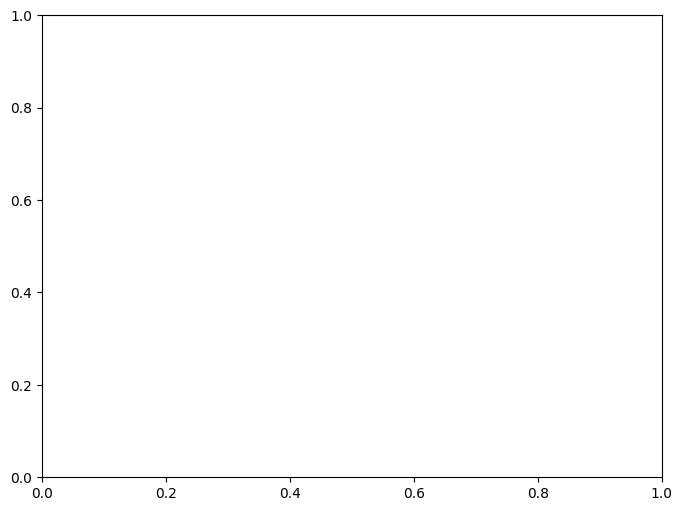

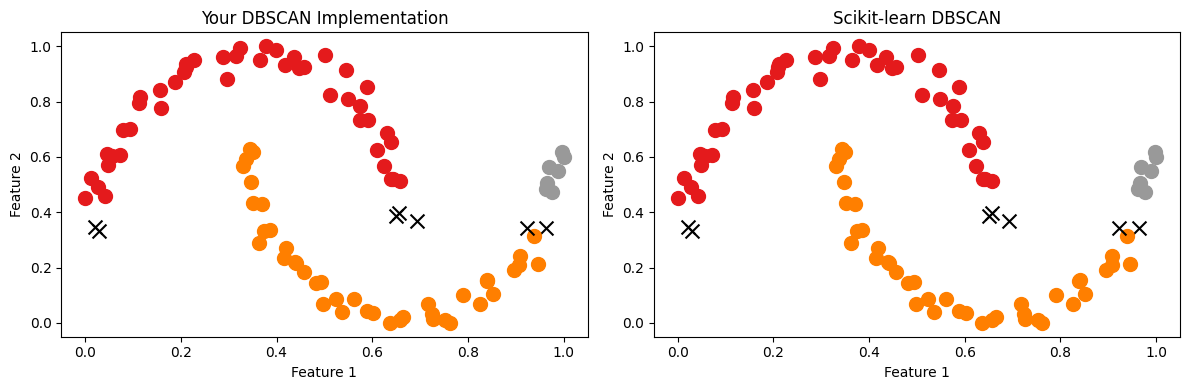

Your implementation: 3 clusters (noise points: 7)
Sklearn: 3 clusters (noise points: 7)


In [7]:

# fit the model with visualization
from IPython import display
import time

# Create an interactive plot function for real-time updates
def plot_clusters_realtime(X, clusters):
    global fig, ax
    ax.clear()
    for i in range(len(clusters)):
        if clusters[i] == -1:
            ax.scatter(X_scaled[i, 0], X_scaled[i, 1], c='k', marker='x', s=100)
        else:
            ax.scatter(X_scaled[i, 0], X_scaled[i, 1], c=plt.cm.Set1(clusters[i] / max(clusters) if max(clusters) > 0 else 0), marker='o', s=100)
    ax.set_title('DBSCAN Clustering (Real-time)')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    display.clear_output(wait=True)
    display.display(fig)
    time.sleep(0.05)

fig, ax = plt.subplots(figsize=(8, 6))
dbscan = DBSCAN(eps=0.1, min_samples=5, visualize=False)
clusters = dbscan.fit(X_scaled, plot_func=plot_clusters_realtime)
print(f"Clustering complete! Found {max(clusters) + 1} clusters")

# Compare with sklearn
print("\nComparing with scikit-learn DBSCAN:")
SklearnDBSCAN = __import__("sklearn.cluster", fromlist=["DBSCAN"]).DBSCAN
dbscan_sklearn = SklearnDBSCAN(eps=0.1, min_samples=5, metric='euclidean')
clusters_sklearn = dbscan_sklearn.fit_predict(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot your implementation
for i in range(len(clusters)):
    if clusters[i] == -1:
        ax1.scatter(X_scaled[i, 0], X_scaled[i, 1], c='k', marker='x', s=100)
    else:
        ax1.scatter(X_scaled[i, 0], X_scaled[i, 1], c=plt.cm.Set1(clusters[i] / max(clusters) if max(clusters) > 0 else 0), marker='o', s=100)
ax1.set_title('Your DBSCAN Implementation')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')

# Plot sklearn implementation
for i in range(len(clusters_sklearn)):
    if clusters_sklearn[i] == -1:
        ax2.scatter(X_scaled[i, 0], X_scaled[i, 1], c='k', marker='x', s=100)
    else:
        ax2.scatter(X_scaled[i, 0], X_scaled[i, 1], c=plt.cm.Set1(clusters_sklearn[i] / max(clusters_sklearn) if max(clusters_sklearn) > -1 else 0), marker='o', s=100)
ax2.set_title('Scikit-learn DBSCAN')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print(f"Your implementation: {max(clusters) + 1} clusters (noise points: {sum(1 for c in clusters if c == -1)})")
print(f"Sklearn: {len(set(clusters_sklearn)) - (1 if -1 in clusters_sklearn else 0)} clusters (noise points: {sum(1 for c in clusters_sklearn if c == -1)})")


In [8]:
# ============ HDBSCAN Algorithm Outline ============
"""
HDBSCAN (Hierarchical DBSCAN) - Algorithm Steps:

1. BUILD MUTUAL REACHABILITY GRAPH
   - Compute k-distance for each point (k = min_samples)
   - Compute mutual reachability distance:
     d_mreach(A, B) = max(k_distance(A), k_distance(B), euclidean_distance(A, B))

2. BUILD MINIMUM SPANNING TREE (MST)
   - Use Prim's or Kruskal's algorithm
   - Input: weighted graph (points as nodes, weights = mutual reachability distances)
   - Output: MST with minimum total edge weight

3. BUILD HIERARCHICAL CLUSTERING DENDROGRAM
   - Convert MST to dendrogram using single-linkage clustering
   - Each edge in MST represents a merge operation at some distance level
   - Track hierarchy levels (distances at which clusters merge)

4. EXTRACT CLUSTERS FROM DENDROGRAM
   - Find optimal cutting threshold using:
     * Stability analysis: measure cluster persistence across hierarchy levels
     * Excess of mass: find most stable clusters
   - Select cluster cut that maximizes cluster stability

5. ASSIGN NOISE POINTS
   - Points not in any selected cluster = NOISE (label = -1)
   - Can assign borderline points to nearest cluster if needed

Key Advantages over DBSCAN:
   - Hierarchical: detects clusters at different densities
   - Parameter-free: no need to choose eps (only min_samples)
   - Better handling of varying density clusters
"""

print(__doc__)


HDBSCAN (Hierarchical DBSCAN) - Algorithm Steps:

1. BUILD MUTUAL REACHABILITY GRAPH
   - Compute k-distance for each point (k = min_samples)
   - Compute mutual reachability distance:
     d_mreach(A, B) = max(k_distance(A), k_distance(B), euclidean_distance(A, B))

2. BUILD MINIMUM SPANNING TREE (MST)
   - Use Prim's or Kruskal's algorithm
   - Input: weighted graph (points as nodes, weights = mutual reachability distances)
   - Output: MST with minimum total edge weight

3. BUILD HIERARCHICAL CLUSTERING DENDROGRAM
   - Convert MST to dendrogram using single-linkage clustering
   - Each edge in MST represents a merge operation at some distance level
   - Track hierarchy levels (distances at which clusters merge)

4. EXTRACT CLUSTERS FROM DENDROGRAM
   - Find optimal cutting threshold using:
     * Stability analysis: measure cluster persistence across hierarchy levels
     * Excess of mass: find most stable clusters
   - Select cluster cut that maximizes cluster stability

5. ASSIGN